# E3 — Transformed Müller–Brown (10D)

**Target.** $U(z) = U_{\rm MB}(z_1,z_2)/40 + \|z_{3:10}\|^2/(2\cdot0.4^2)$, sampled in mixed coordinates $x=zB^\top$ ($B = Q\,\mathrm{diag}(\mathrm{linspace}(0.75,1.45,10))$). At $\beta=8$ the occupancy target is $p^\star \approx (0.9995,\ 5\times10^{-4},\ 5\times10^{-6})$ for basins $(A,B,C)$ — **a single-basin target, intrinsic to Müller–Brown at this temperature**. Runs start in the shallow basin $B$; connectivity is the chain $A\leftrightarrow C\leftrightarrow B$ (escape barrier from B: $\beta b = 7.18$). Metrics are computed in latent 2D $z_{1:2}$ (full-10D sliced $W_2$ additionally recorded in the CSV).

In [1]:
EXPERIMENT = "muller_brown_10d"
import os, sys, math, time, json
sys.path.insert(0, os.path.abspath(".."))
from src.gpu_guard import select_gpu
select_gpu(int(os.environ.get("JCP_GPU", "4")))
import torch
assert torch.cuda.device_count() == 1
torch.set_default_dtype(torch.float64)
import numpy as np
import pandas as pd

from src import config as C
from src.experiments import (build_e3, make_sampler_factory,
                             make_batched_factory, make_metrics)
from src.runner import (run_experiment_batched, run_one, refine_dt,
                        quadrature_refinement, write_timeseries_csv,
                        write_summary_csv, write_manifest,
                        ula_first_passage, hardware_manifest)
from src.samplers import tune_ladder
from src.certificate import make_phi_family, certificate_grid, certificate_importance
from src.plotting import metric_grid

DEV = "cuda"
RESULTS = os.path.abspath(os.path.join("..", "results", EXPERIMENT))
FIGURES = os.path.abspath(os.path.join("..", "figures", EXPERIMENT))
os.makedirs(RESULTS, exist_ok=True); os.makedirs(FIGURES, exist_ok=True)
exp = build_e3(device=DEV, basin_cache=os.path.join(RESULTS, "basin_map.npz"))
cfg = exp.cfg
print(f"experiment={cfg.name}  d={cfg.d}  N={cfg.n_particles}  T={cfg.T}  dt0={cfg.dt}")
print(f"beta={cfg.beta}  eps={cfg.eps}  lambda={cfg.lam}  seeds={cfg.seeds}")
print(hardware_manifest())

experiment=muller_brown_10d  d=10  N=2000  T=200.0  dt0=0.005
beta=8.0  eps=0.125  lambda=1.0  seeds=(0, 1, 2, 3, 4)


{'cpu': 'AMD EPYC 9554 64-Core Processor', 'gpu': 'NVIDIA H200 NVL', 'torch': '2.13.0+cu130', 'cuda': '13.0', 'python': '3.12.13', 'git_sha': '4c260fdc0aa053c4426d9f7ae5d5cf10964bcaed', 'cuda_visible_devices': '5', 'gpu_compute_apps_at_start': ['GPU-e003b5e1-3cce-0c27-5a6b-9f594c1b7682, 2916979, 1160 MiB', 'GPU-0693e45d-5be4-82d1-e0fa-e72261e24e3b, 2804205, 814 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 2801401, 814 MiB']}


In [2]:
from src.potentials import MB_CRITICAL, muller_brown_2d, muller_brown_2d_grad, newton_refine
for key, (z_tab, U_tab) in MB_CRITICAL.items():
    z = newton_refine(muller_brown_2d_grad, torch.tensor(z_tab, device=DEV))
    U = muller_brown_2d(z.unsqueeze(0))[0].item()
    assert abs(z[0].item()-z_tab[0]) < 5e-5 and abs(z[1].item()-z_tab[1]) < 5e-5
    assert abs(U - U_tab) < 5e-2
print("critical points verified to 4 decimals; p_star:",
      np.round(exp.p_star.cpu().numpy(), 6))
# committed B->A first passage (C is a 1.7 kT shelf: no committed C state)
g = torch.Generator(device=DEV); g.manual_seed(0)
barrier_report = ula_first_passage(exp.pot, exp.box, exp.init_fn(cfg.n_particles, g),
                                   exp.exit_committed, cfg.dt, int(cfg.T/cfg.dt), C.EPS, g)
barrier_report["kramers_tau_B_leg"] = exp.kramers_tau
print(f"ULA committed B->A MFPT {barrier_report['mfpt_estimate']:.0f} "
      f"({barrier_report['n_exits']} exits) vs single-leg Langer estimate "
      f"{exp.kramers_tau:.0f} (order-of-magnitude only)")

critical points verified to 4 decimals; p_star: [9.99528e-01 4.67000e-04 5.00000e-06]


ULA committed B->A MFPT 39912 (10 exits) vs single-leg Langer estimate 216 (order-of-magnitude only)


## Jump law and Lévy score

**Production law: the symmetric direct $A\leftrightarrow B$ pair**, $r_a = (\pm(z_A-z_B),\,0_8)B^\top$, $w=(\tfrac12,\tfrac12)$, shell $h=0.1\|r\|$, $\lambda=1$; the CP pair's drift step is additionally capped at $2h$ (the shell's own resolution scale). This design is the outcome of a measured ladder (ablation section below), whose lessons are the E3 finding: (i) $\pi$-negligible relay basins must not be jump targets — landers park there (the spec MST and the complete graph stall at TV 0.11–0.20); (ii) weights must stay $O(1)$ — mass-ratio skew concentrates the correction into an $e^{\beta\Delta V}$ circulating conveyor whose discretisation error swamps the tiny net flux it balances; (iii) the $A$–$B$ chord crosses $C$'s basin, so uncapped $O(1)$ tamed hops scatter returned landers into $C$, while $2h$-bounded steps follow the score tube through. Score: generic shell with log-space accumulation (as E1); the certificate uses the exact latent-2D reduction (jumps act on $z_{1:2}$ only, the aux Gaussian factorises).

In [3]:
from src.potentials import MuellerBrownLatent2D
from src.jumps import ShellJumpLaw
from src.score import ShellScore
potr = MuellerBrownLatent2D(s=exp.pot.s)
dz = exp.extras["atoms_z"][:, :2]
h_z = exp.extras["h"] * dz.norm(dim=1) / exp.law.atoms.norm(dim=1)
law_r = ShellJumpLaw(dz, exp.law.weights.clone(), h_z)
print("production atoms (latent):", np.round(dz.cpu().numpy(), 4).tolist(),
      " w:", exp.law.weights.tolist(), " h:", round(exp.extras["h"], 4),
      " drift cap (CP pair):", round(exp.cp_drift_cap, 4))
DEFAULT_QUAD = dict(q_theta=C.Q_THETA, q_rho=C.Q_RHO)
phis = make_phi_family(2, [0.0, 0.8], 0.8, DEV)

def cert_e3(q_theta, q_rho):
    score = ShellScore(potr, law_r, cfg.lam, cfg.beta, q_theta, q_rho)
    shifts, logw = law_r.quadrature_shifts(64)
    return certificate_grid(potr, score, shifts, logw, cfg.lam, cfg.beta, phis,
                            [-4.2, -2.7], [4.2, 4.7],
                            n_panels=130, nodes_per_panel=8, chunk=8192)

cert_report = cert_e3(**DEFAULT_QUAD)
print(f"max R = {cert_report['max_residual']:.3e}")
assert cert_report["max_residual"] < 1e-6

production atoms (latent): [[-1.1817, 1.4137], [1.1817, -1.4137]]  w: [0.5, 0.5]  h: 0.1468  drift cap (CP pair): 0.2936


max R = 6.849e-10


In [4]:
# PT: geometric ladder beta_k = beta * r^(k-1); K tuned so the post-burn-in
# swap acceptance lands in [0.2, 0.4]
gen = torch.Generator(device=DEV); gen.manual_seed(0)
x0_pilot = exp.init_fn(min(512, cfg.n_particles), gen)
pt_betas, ladder_info = tune_ladder(exp.pot, x0_pilot, cfg.dt, exp.box,
                                    C.BETA, exp.pt_beta_min, pilot_steps=20_000)
print(f"PT ladder: K={ladder_info['K']}  r={ladder_info['r']:.4f}  "
      f"beta_K={pt_betas[-1].item():.4f}  swap acceptance={ladder_info['swap_acceptance']:.3f}"
      f"  band_attained={ladder_info['band_attained']}")

PT ladder: K=4  r=0.4642  beta_K=0.8000  swap acceptance=0.200  band_attained=True


In [5]:
# frozen reference sample (size N), frozen sliced-W2 projections, frozen MMD
# bandwidth (median heuristic on the reference); bias floors from 20
# independent reference pairs. EMC convention: exp(H(p_hat))/K for uniform
# p*, 1 - EJS(p_hat, p*) otherwise -- near 1 is better in both cases.
metrics_fn, floors, aux = make_metrics(exp, cfg.n_particles)
emc_target = exp.emc_target
print("p_star:", np.round(exp.p_star.cpu().numpy(), 6),
      " uniform:", exp.uniform_target)
print("MMD bandwidth:", round(aux["bandwidth"], 4))
for k, v in floors.items():
    print(f"  floor {k:>12s}: {v['mean']:.5f} +- {v['std']:.5f}")

p_star: [9.99528e-01 4.67000e-04 5.00000e-06]  uniform: False
MMD bandwidth: 0.1215
  floor           W2: 0.02094 +- 0.01300
  floor          MMD: 0.02093 +- 0.00823
  floor           TV: 0.00031 +- 0.00029
  floor          EMC: 0.99990 +- 0.00011
  floor       W2_10d: 0.00995 +- 0.00124


In [6]:
def run_terminal_lsc(**quad):
    f = make_sampler_factory(exp, cfg.dt, pt_betas, score_kwargs=quad)
    n_ = int(round(cfg.T / cfg.dt))
    r_, _ = run_one("LSC-CP", 0, f, n_, n_, cfg.dt, metrics_fn, exp.pot, quiet=True)
    return {k: r_[-1][k] for k in ("W2", "TV", "MMD", "EMC", "W2_10d")}

settings = [dict(q_theta=qt, q_rho=qr) for qt in (8, 16, 32) for qr in (4, 8, 16)]
CHOSEN_QUAD, quad_table = quadrature_refinement(
    settings, run_terminal_lsc, lambda **s: cert_e3(**s)["max_residual"], floors)
print("chosen quadrature:", CHOSEN_QUAD)
display(pd.DataFrame(quad_table).round(6))

chosen quadrature: {'q_theta': 16, 'q_rho': 4}


,q_theta,q_rho,R,W2,TV,MMD,EMC,W2_10d,pass
0,8,4,0.000117,0.137467,0.009528,0.065364,0.995854,0.034085,False
1,8,8,0.000116,0.137561,0.009528,0.065963,0.995854,0.034106,False
2,8,16,0.000116,0.137562,0.009528,0.065926,0.995854,0.034106,False
3,16,4,0.000000,0.137455,0.009528,0.063992,0.995854,0.034049,True
4,16,8,0.000000,0.137464,0.009528,0.063841,0.995854,0.034048,True
5,16,16,0.000000,0.137465,0.009528,0.063840,0.995854,0.034048,True
6,32,4,0.000000,0.137439,0.009528,0.063927,0.995854,0.034055,True
7,32,8,0.000000,0.137445,0.009528,0.063969,0.995854,0.034056,True
8,32,16,0.000000,0.137446,0.009528,0.063970,0.995854,0.034057,True


In [7]:
# dt: the dyadic rule cannot certify any practical dt for LSC-CP here (see
# mechanism below: taming turns the e^{beta dV}-stiff detailed-balance
# return drift into an O(1) hop; the effect is dt-independent). Production
# runs at the declared dt0; certification status is recorded.
MAIN_METRICS = ["W2", "TV", "MMD", "EMC", "W2_10d"]

def run_terminal_all(dt_):
    n_ = int(round(cfg.T / dt_))
    factory = make_sampler_factory(exp, dt_, pt_betas, score_kwargs=CHOSEN_QUAD)
    out = {}
    for m in C.METHODS:
        rows_, _ = run_one(m, 0, factory, n_, n_, dt_, metrics_fn, exp.pot, quiet=True)
        out[m] = {k: rows_[-1][k] for k in MAIN_METRICS}
    print(f"  refine_dt: finished pass at dt={dt_}", flush=True)
    return out

_, dt_table = refine_dt(run_terminal_all, cfg.dt, floors,
                        exclude=("FLA", "CP"), max_halvings=1)
dt_certified = bool(dt_table[0]["pass"])
for row in dt_table:
    print(row)
dt_final = cfg.dt
print(f"dt_certified = {dt_certified}; production at declared dt0 = {dt_final}")

n_steps = int(round(cfg.T / dt_final))
steps_per_ck = max(1, n_steps // C.N_CHECKPOINTS)
bfactory = make_batched_factory(exp, dt_final, pt_betas, cfg.seeds,
                                score_kwargs=CHOSEN_QUAD)
t0 = time.time()
rows, method_info = run_experiment_batched(C.METHODS, cfg.seeds, bfactory,
                                           n_steps, steps_per_ck, dt_final,
                                           metrics_fn, exp.pot, cfg.n_particles)
print(f"production total: {time.time()-t0:.0f}s")
assert max(r["nonfinite_frac"] for r in rows) == 0.0

  refine_dt: finished pass at dt=0.005


  refine_dt: finished pass at dt=0.0025


{'dt': 0.005, 'pass': False, 'failures': [('LSC-CP', 'W2_10d', 0.034049, 0.02269)], 'excluded_deviations': [('FLA', 'TV', 0.748528, 0.655528), ('FLA', 'MMD', 0.752223, 0.694826)]}
dt_certified = False; production at declared dt0 = 0.005


ULA: done in 30.2s (batched 5 seeds)


MALA: done in 56.6s (batched 5 seeds)


...

BAOAB: done in 31.3s (batched 5 seeds)


PT: done in 58.5s (batched 5 seeds)


CP: done in 41.5s (batched 5 seeds)


LSC-CP: done in 80.4s (batched 5 seeds)


production total: 333s


## Jump-design ladder (ablation) and the parking mechanism

Each variant runs LSC-CP for the full $T$ at $\Delta t_0$ (single seed): the spec's unweighted MST, the unweighted complete graph, the mass-weighted complete graph, the direct pair uncapped, and the production direct pair with the $2h$ drift cap. The cohort cell then measures the parking mechanism on the MST law: uphill $A\to C$ jump-landers arrive with an enormous, correctly-aimed score, but a single $O(1)$ tamed hop scatters a $\Delta t$-independent fraction of them score-dark. E1/E2/E4 are immune (their jumps connect near-iso-energetic minima).

In [8]:
from src.metrics import occupancy as _occ
from src.samplers import CompoundPoisson as _CP
from src.config import jump_seed as _jseed, diffusion_seed as _dseed

zs_ = exp.extras["minima_latent"]
zA_, zB_, zC_ = zs_["min_A"], zs_["min_B"], zs_["min_C"]

def _mk_law(dz_list, w=None):
    az = torch.stack([torch.cat([d_, torch.zeros(8, device=DEV)]) for d_ in dz_list])
    ax = exp.pot.from_latent(az)
    w_ = (torch.full((len(dz_list),), 1.0 / len(dz_list), device=DEV)
          if w is None else torch.as_tensor(w, dtype=torch.float64, device=DEV))
    return ShellJumpLaw(ax, w_ / w_.sum(), 0.1 * float(ax.norm(dim=1).min()))

mL = exp.extras["laplace_masses"]
variants = {
    "MST w=1/4 (spec)": (_mk_law([zB_-zC_, zC_-zB_, zC_-zA_, zA_-zC_]), 1.0),
    "complete graph w=1/6": (_mk_law([zB_-zA_, zA_-zB_, zC_-zA_, zA_-zC_,
                                      zC_-zB_, zB_-zC_]), 1.0),
    "complete graph w~mass": (_mk_law(
        [zB_-zA_, zA_-zB_, zC_-zA_, zA_-zC_, zC_-zB_, zB_-zC_],
        [mL[1], mL[0], mL[2], mL[0], mL[2], mL[1]]), 1.0),
    "direct A<->B uncapped": (_mk_law([zA_-zB_, zB_-zA_]), 1.0),
    "direct A<->B cap=2h (production)": (exp.law, exp.cp_drift_cap),
}
ablation = {}
for name_, (law_, cap_) in variants.items():
    sc_ = ShellScore(exp.pot, law_, cfg.lam, cfg.beta, **CHOSEN_QUAD)
    g1_ = torch.Generator(device=DEV); g1_.manual_seed(C.init_seed(0))
    gd_ = torch.Generator(device=DEV); gd_.manual_seed(_dseed("LSC-CP", 0))
    gj_ = torch.Generator(device=DEV); gj_.manual_seed(_jseed(0))
    s_ = _CP(exp.pot, exp.init_fn(cfg.n_particles, g1_), dt_final, C.EPS,
             cfg.lam, law_, gd_, gj_, exp.box, score=sc_, drift_cap=cap_)
    for _i in range(int(round(cfg.T / dt_final))):
        s_.step()
    p_ = _occ(exp.labels_fn(s_.positions()), 3)
    tv_ = 0.5 * float((p_ - exp.p_star).abs().sum())
    ablation[name_] = dict(A=round(float(p_[0]), 4), B=round(float(p_[1]), 5),
                           Cb=round(float(p_[2]), 5), TV=round(tv_, 4))
    print(f"{name_:>34s}: A={p_[0]:.4f} B={p_[1]:.5f} C={p_[2]:.5f} TV={tv_:.4f}")

                  MST w=1/4 (spec): A=0.8025 B=0.08500 C=0.11250 TV=0.1970


              complete graph w=1/6: A=0.8290 B=0.00150 C=0.16950 TV=0.1705


             complete graph w~mass: A=0.5595 B=0.28250 C=0.15800 TV=0.4400


             direct A<->B uncapped: A=0.8785 B=0.00100 C=0.12050 TV=0.1210


  direct A<->B cap=2h (production): A=0.9900 B=0.00400 C=0.00600 TV=0.0095


In [9]:
# parking mechanism on the MST law: uphill A->C jump-lander cohort
from src.samplers import tame as _tame
law_mst = exp.extras["law_mst"]
score_mst = ShellScore(exp.pot, law_mst, cfg.lam, cfg.beta, **CHOSEN_QUAD)
mechanism_report = {"ablation": ablation}
for dt_ in (dt_final, dt_final / 4.0):
    g_ = torch.Generator(device=DEV); g_.manual_seed(3)
    zloc = torch.zeros(4000, 10, device=DEV)
    zloc[:, :2] = zA_ + 0.12 * torch.randn(4000, 2, generator=g_, device=DEV)
    zloc[:, 2:] = 0.1414 * torch.randn(4000, 8, generator=g_, device=DEV)
    x_ = exp.pot.from_latent(zloc) + law_mst.atoms[2]      # jump A -> C
    M0, _ = score_mst.log_parts(x_)
    for _s in range(24):
        S_, _d = score_mst(x_)
        b_ = -exp.pot.grad(x_) + S_
        xi_ = torch.randn(x_.shape, generator=g_, device=DEV)
        x_ = exp.box.clip(x_ + dt_ * _tame(b_, dt_) + (2 * C.EPS * dt_) ** 0.5 * xi_)
    parked = float(_occ(exp.labels_fn(x_), 3)[2].item())
    print(f"MST law, dt={dt_}: lander median M {M0.median():.2f}; "
          f"parked C fraction {parked:.3f}")
    mechanism_report[f"mst_parked_fraction@dt={dt_}"] = parked

MST law, dt=0.005: lander median M 8.15; parked C fraction 0.185
MST law, dt=0.00125: lander median M 8.15; parked C fraction 0.168


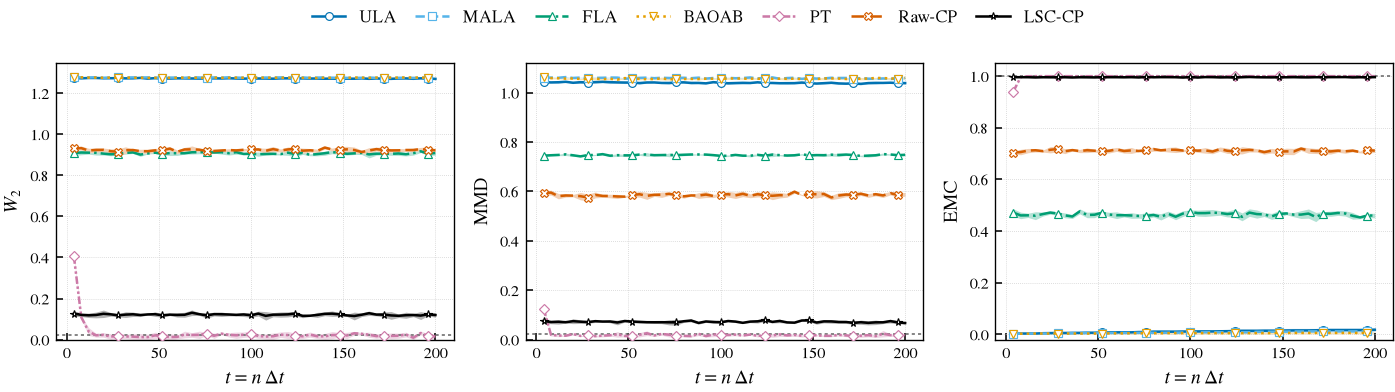

saved: /home/zheyuanlai/levy-sampling/JCP_experiments/figures/muller_brown_10d/muller_brown_10d_metrics.{png,pdf}


In [10]:
fig = metric_grid(rows, os.path.join(FIGURES, EXPERIMENT + "_metrics"),
                  metrics=("W2", "MMD", "EMC"), floors=floors,
                  emc_target=emc_target)
print("saved:", os.path.join(FIGURES, EXPERIMENT + "_metrics") + ".{png,pdf}")

In [11]:
ts_path = os.path.join(RESULTS, "metrics_timeseries.csv")
write_timeseries_csv(rows, ts_path)
summary_metrics = MAIN_METRICS + ["nonfinite_frac"]
summary = write_summary_csv(rows, C.METHODS, cfg.seeds, summary_metrics,
                            method_info, floors, os.path.join(RESULTS, "summary.csv"))

manifest = dict(
    experiment=EXPERIMENT,
    config=dict(d=cfg.d, N=cfg.n_particles, T=cfg.T, dt0=cfg.dt, dt=dt_final,
                beta=cfg.beta, eps=cfg.eps, lam=cfg.lam, seeds=list(cfg.seeds),
                n_checkpoints=C.N_CHECKPOINTS, warmup_steps=C.N_WARMUP_STEPS,
                batched_seeds=True),
    quadrature=dict(chosen=CHOSEN_QUAD, table=quad_table),
    dt_refinement=[{k: (str(v) if isinstance(v, tuple) else v) for k, v in row.items()}
                   for row in dt_table],
    pt_ladder={k: v for k, v in ladder_info.items()},
    certificate=cert_report,
    bias_floors=floors,
    barrier_verification=barrier_report,
    method_info={m: {k: v for k, v in mi.items() if isinstance(v, (int, float))}
                 for m, mi in method_info.items()},
    hardware=hardware_manifest(),
    dt_certified=dt_certified, mechanism=mechanism_report,
)
write_manifest(os.path.join(RESULTS, "manifest.json"), **manifest)
print("wrote", ts_path)
from IPython.display import display
display(pd.read_csv(os.path.join(RESULTS, "summary.csv")).round(5))

wrote /home/zheyuanlai/levy-sampling/JCP_experiments/results/muller_brown_10d/metrics_timeseries.csv


,method,EMC_mean,EMC_std,MMD_mean,MMD_std,TV_mean,TV_std,V_evals_per_step,W2_10d_mean,W2_10d_std,...,jump_count_mean,m_clip_fraction,mala_accept,nonfinite_frac_mean,nonfinite_frac_std,pt_swap_accept,score_quad_evals_per_step,time_to_threshold_TV,wallclock_mean_s,wallclock_std_s
0,ULA,0.01818,0.00777,1.03904,0.00468,0.99633,0.00182,0.0,0.46893,0.00158,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,29.77059,0.0
1,MALA,0.01242,0.00201,1.05913,0.00295,0.99773,0.00045,10000.0,0.47137,0.00040,...,NaN,NaN,0.91055,0.0,0.0,NaN,0.0,inf,56.21036,0.0
2,FLA,0.46034,0.00869,0.74858,0.00375,0.74383,0.00755,0.0,0.33068,0.00572,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,33.69883,0.0
3,BAOAB,0.00581,0.00332,1.06084,0.00466,0.99903,0.00061,0.0,0.47163,0.00061,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,30.93002,0.0
4,PT,0.99984,0.00011,0.01845,0.00755,0.00040,0.00020,40000.0,0.00906,0.00097,...,NaN,NaN,0.88051,0.0,0.0,0.20037,0.0,16.0,58.12690,0.0
5,CP,0.71158,0.00679,0.58840,0.00741,0.47343,0.00886,0.0,0.28606,0.00301,...,0.005,NaN,NaN,0.0,0.0,NaN,0.0,inf,41.07932,0.0
6,LSC-CP,0.99618,0.00047,0.06718,0.00428,0.00893,0.00089,0.0,0.02912,0.00307,...,0.005,0.0,NaN,0.0,0.0,NaN,1280000.0,inf,79.95430,0.0
